<a href="https://colab.research.google.com/github/Thiago1717/Sztuczna_Inteligencja/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oliwier Bogdański 21181



# Lab 1

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [2]:
observations=1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(-10, 10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(1000, 2)


In [3]:
noise = np.random.uniform(low=-1,high=1, size=(observations,1))
targets = 13*xs + 7*zs - 12 + noise
np.savez('TF_dataset' , inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


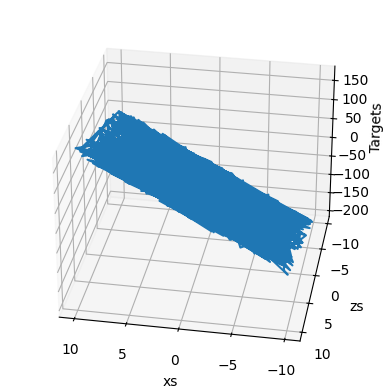

In [4]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [5]:
init_range = 0.2
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights,biases)

[[ 0.03619332]
 [-0.05366682]] [-0.12247519]


In [6]:
targets = targets.reshape(observations,1)
eta = 0.1
for i in range (100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) /2/ observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

3649.468980550066
19055.57466457138
100924.0409015358
535744.7784874644
2845188.125550689
15112374.174059056
80279767.34464215
426510943.2857136
2266242450.683359
12043051987.328352
64006303577.42386
340225603011.5805
1808720343737.721
9616969225536.797
51141050976741.91
271999433417536.88
1446890442310115.0
7697948917289744.0
4.096270443131967e+16
2.1801129291232506e+17
1.1605096130141857e+18
6.178748916377752e+18
3.2903123956310696e+19
1.7525131508054435e+20
9.336322452789525e+20
4.97489246485757e+21
2.651476572776312e+22
1.4134847433016822e+23
7.536969010760909e+23
4.019830026984638e+24
2.1445053245246074e+25
1.1443482398741099e+26
6.108071520701121e+26
3.2611297119481835e+27
1.7416197081791943e+28
9.303859658765353e+28
4.971653054702517e+29
2.6574775782452415e+30
1.4209304737544938e+31
7.600002970045151e+31
4.0662651158403256e+32
2.1763156241276394e+33
1.1651868445330532e+34
6.240508545144784e+34
3.343476579334785e+35
1.7919818819090562e+36
9.607912723902843e+36
5.153325927928893e+

In [7]:
print (weights, biases)

[[-9.87222232e+36]
 [-5.00897466e+37]] [-8.37807954e+34]


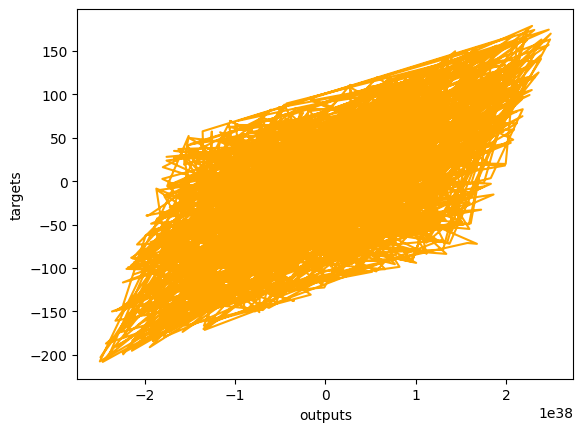

In [8]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

# Wnioski
Przy bardzo małych wartościach współczynnika uczenia (0,0001 i 0,001) model uczy się zbyt wolno, przez co funkcja straty spada tylko nieznacznie i algorytm nie zdąży znaleźć optymalnych wag w zaplanowanych 100 epokach. Z kolei wartość 0,2 pozwala na optymalny i bardzo szybki spadek błędu do pożądanych wartości, podczas gdy zbyt duży krok rzędu 1 sprawia, że model całkowicie "rozbiega się", a błąd gwałtownie rośnie do nieskończoności